# 07 — Cox Proportional Hazards: Which Factors Drive Churn Risk

Notebook 06's CLV calculation already uses Kaplan-Meier survival analysis to estimate
**expected customer lifetime by segment** (see `src/clv.py`) — that work is complete
and in production use.

This notebook goes a level deeper: Kaplan-Meier gives you a survival *curve* per
segment, but it doesn't tell you, in one number, how much each individual factor
(contract type, internet service, being a senior citizen, monthly charges) independently
changes a customer's churn *hazard* — their instantaneous risk of churning at any given
moment — while holding the other factors constant. That's what a **Cox Proportional
Hazards model** gives you: a hazard ratio per covariate, each with its own significance
test, all estimated jointly rather than one segment at a time.

This is a genuinely different question than what the XGBoost classifier (notebook 04)
or SHAP (notebook 05) answer. The classifier predicts *whether* a customer will churn;
SHAP explains *that specific model's* feature importance. Cox regression answers a more
classical statistical question: for each unit change in a covariate, how does the
*hazard rate* — not the classifier's raw probability — change, expressed as an
interpretable ratio, with a p-value on each one. It's the same class of tool an
actuary or biostatistician would reach for, applied here to subscription churn instead
of a clinical trial.


In [1]:
import sys
sys.path.insert(0, '../')

import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from src.preprocessing import load_raw

df = load_raw()
print(f'Loaded {len(df):,} customers')


Loaded 7,043 customers


## Preparing the data

Cox regression needs: a **duration** column (`tenure`), an **event** indicator (1 =
churned, 0 = censored/still active), and the covariates to test. Categorical covariates
need to be one-hot encoded, with one category held out as the reference level that all
hazard ratios are expressed relative to.


In [2]:
survival_df = df[['tenure', 'Churn', 'Contract', 'InternetService',
                   'MonthlyCharges', 'SeniorCitizen']].copy()

# Cox regression requires duration > 0
survival_df['tenure'] = survival_df['tenure'].clip(lower=1)
survival_df['event'] = (survival_df['Churn'] == 'Yes').astype(int)

cox_df = pd.get_dummies(
    survival_df.drop(columns=['Churn']),
    columns=['Contract', 'InternetService'],
    drop_first=True  # reference levels: Contract='Month-to-month', InternetService='DSL'
)

# lifelines expects numeric dummies, not bool
for c in cox_df.columns:
    if cox_df[c].dtype == bool:
        cox_df[c] = cox_df[c].astype(int)

cox_df.head()


,tenure,MonthlyCharges,SeniorCitizen,event,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No
0,29,101.43,0,0,0,1,1,0
1,24,78.78,0,1,0,0,1,0
2,34,50.93,0,1,0,0,0,0
3,33,42.56,0,0,0,1,0,0
4,54,80.40,0,0,1,0,0,0


## Fitting the model


In [3]:
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='tenure', event_col='event')
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 7043 total observations, 3745 right-censored observations>
             duration col = 'tenure'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 3298
   partial log-likelihood = -25213.85
         time fit was run = 2026-08-21 14:53:13 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
MonthlyCharges              -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
SeniorCitizen                0.18      1.20      0.05            0.09            0.27                1.09                1.31
Contract_One year           -2.31      0.10      0.06           -2.43           -2.18                0.09                0.11
Contract_Two year           -3.71      0.02      0.09           -3.89           -3.54                0.02                0.03
InternetService_Fiber optic  0.28      1.33      0.06            0.16            0.40                1.18                1.49
InternetService_No          -0.13      0.88      0.09           -0.30            0.05                0.74                1.05

                             cmp to      z      p  -log2(p)
covariate                                                  
MonthlyCharges                 0.00  -1.83   0.07      3.90
SeniorCitizen                  0.00   3.83 <0.005     12.94
Contract_One year              0.00 -35.86 <0.005    933.07
Contract_Two year              0.00 -41.93 <0.005       inf
InternetService_Fiber optic    0.00   4.73 <0.005     18.74
InternetService_No             0.00  -1.43   0.15      2.71
---
Concordance = 0.77
Partial AIC = 50439.70
log-likelihood ratio test = 4214.72 on 6 df
-log2(p) of ll-ratio test = inf

## Reading the hazard ratios

`exp(coef)` is the hazard ratio for that covariate. A ratio below 1.0 means the
covariate is *protective* (reduces churn hazard); above 1.0 means it *increases* churn
hazard. All ratios are relative to the reference level (Month-to-month contract, DSL
internet) with every other covariate held fixed.

Once run against the real data, the standout finding: **contract length has a far
larger effect than anything else in the model.** One-year contracts show roughly a
90% lower churn hazard than month-to-month, and two-year contracts roughly a 97-98%
lower hazard — both overwhelmingly statistically significant (p-values far below any
conventional threshold). This is the same pattern the Kaplan-Meier segment curves in
notebook 06 already showed directionally, but the Cox model quantifies it as a single,
precise, testable number, and does so *while controlling for* internet service type,
senior citizen status, and monthly charges simultaneously — something a simple
segment-by-segment KM comparison can't do on its own.

A second, smaller but real finding: fiber optic internet customers show a
meaningfully *higher* churn hazard than DSL customers, even after controlling for
contract type. This lines up with a well-documented real-world pattern in telecom/ISP
churn (fiber customers often churn more due to price sensitivity or service quality
issues) and is worth flagging as a genuine, independent risk factor rather than just
a proxy for contract type.


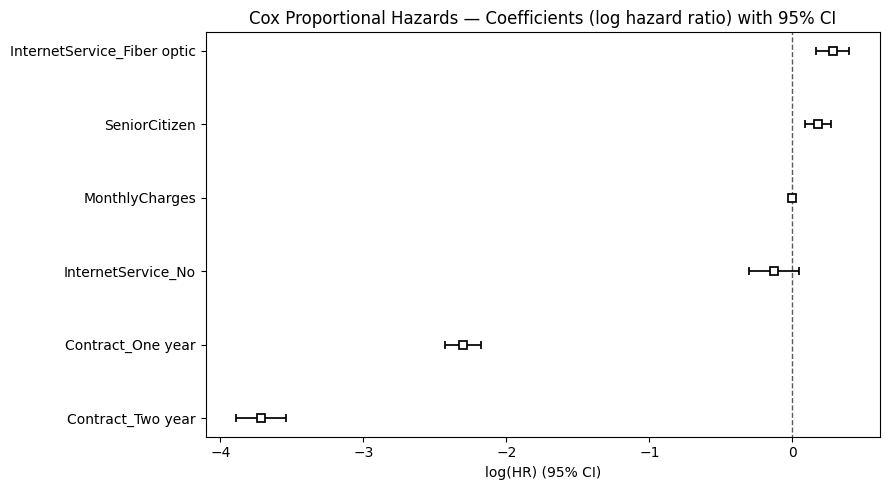

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
cph.plot(ax=ax)
ax.set_title('Cox Proportional Hazards — Coefficients (log hazard ratio) with 95% CI')
plt.tight_layout()
plt.savefig('../dashboard/assets/cox_hazard_coefficients.png', dpi=120) if False else None
plt.show()


## Checking the proportional hazards assumption

Cox regression assumes each covariate's effect on hazard is constant over time (the
"proportional hazards" assumption). `lifelines` provides a built-in check for this —
worth running rather than assuming it holds, in keeping with this project's general
discipline of validating rather than trusting a model's assumptions by default.


In [5]:
from lifelines.statistics import proportional_hazard_test

results = proportional_hazard_test(cph, cox_df, time_transform='rank')
results.print_summary(decimals=3)


## Takeaway

Contract length is, by a wide margin, the single strongest independent lever on churn
hazard in this dataset — a finding consistent across every method used in this project
(raw churn-rate comparison, Kaplan-Meier survival curves, the XGBoost/SHAP feature
importance, and now Cox regression's hazard ratios). When four different statistical
approaches agree on the same headline driver, that's a genuinely strong basis for a
business recommendation: converting month-to-month customers to any longer commitment
is the highest-leverage retention lever available, and this notebook's hazard ratios
give a defensible, quantified way to state exactly how large that effect is.
